# Reconocimiento de Expresiones Cara

Lucho Nov| 2023 <br>
Unchain My Heart by Hugh Laurie

Este ejercicio consiste en el desarrollo de un sistema relacionado con el reconocimiento de emociones. El objetivo principal es identificar, a partir de un rostro, la expresión emocional que presenta una persona.

### Emociones detectadas

- **Angry** (enojo)  
- **Disgust** (asco)  
- **Fear** (miedo)  
- **Happy** (felicidad)  
- **Neutral** (neutralidad)  
- **Sad** (tristeza)  
- **Surprise** (sorpresa)

### Desarrollo futuro

Posteriormente, el proyecto se amplía hacia la **detección de emociones en tiempo real**, integrando una funcionalidad adicional: la **clasificación de mentiras**, basada en las microexpresiones faciales observadas durante una conversación o interacción.


Dataset: https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset/data

## Import Packages

In [1]:
import os
import pickle
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
import cv2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalMaxPooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator



## Import dataset

In [2]:
data_dir = 'E:\\Trabajo\\emociones\\images\\images'
train_dir = os.path.join(data_dir, 'train')
validation_dir = os.path.join(data_dir, 'validation')

In [3]:
# Generador de datos de imagen para el conjunto de entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normaliza los píxeles al rango [0, 1]
    rotation_range=20,           # Rota aleatoriamente las imágenes hasta 20 grados
    zoom_range=0.2,              # Aplica zoom aleatorio hasta un 20%
    horizontal_flip=True         # Invierte las imágenes horizontalmente (simetría)
)

# Generador de datos de imagen para el conjunto de validación (solo normalización)
validation_datagen = ImageDataGenerator(
    rescale=1./255               # Normaliza los píxeles al rango [0, 1]
)

# Carga y preprocesamiento de imágenes desde el directorio de entrenamiento
train_generator = train_datagen.flow_from_directory(
    train_dir,                   # Ruta al directorio de entrenamiento
    target_size=(48, 48),        # Redimensiona todas las imágenes a 48x48 píxeles
    batch_size=64,               # Número de imágenes por lote (batch)
    class_mode='categorical',    # Las etiquetas se codifican como vectores one-hot
    color_mode='grayscale'       # Convierte las imágenes a escala de grises
)

# Carga y preprocesamiento de imágenes desde el directorio de validación
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,              # Ruta al directorio de validación
    target_size=(48, 48),        # Redimensiona todas las imágenes a 48x48 píxeles
    batch_size=64,               # Número de imágenes por lote (batch)
    class_mode='categorical',    # Las etiquetas se codifican como vectores one-hot
    color_mode='grayscale'       # Convierte las imágenes a escala de grises
)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


### Analisis de Datos (EDA)

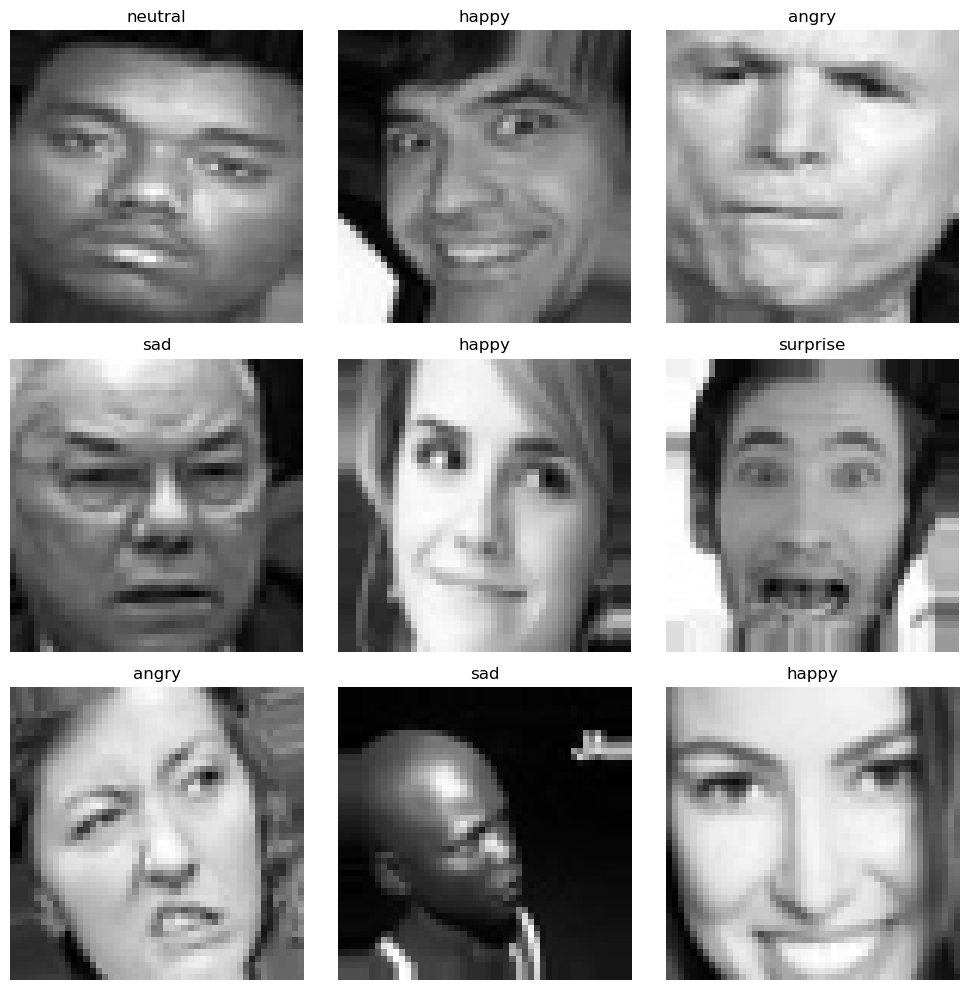

In [4]:
class_names = list(train_generator.class_indices.keys())

images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].reshape(48, 48), cmap='gray')
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis('off')
plt.tight_layout()
plt.show()

### RedNeuronal

In [ ]:
# Definición del modelo secuencial
model = Sequential([

    # Primera capa convolucional
    Conv2D(64, (3, 3), activation='relu', input_shape=(48, 48, 1)),   # 64 filtros 3x3, ReLU, entrada de 48x48x1 (escala de grises)
    BatchNormalization(),                                            # Normaliza activaciones para mayor estabilidad
    MaxPooling2D(2, 2),                                              # Reduce tamaño espacial a la mitad (48x48 -> 24x24)
    Dropout(0.25),                                                   # Desactiva 25% de neuronas (previene overfitting)

    # Segunda capa convolucional
    Conv2D(128, (3, 3), activation='relu'),                          # 128 filtros 3x3, ReLU
    BatchNormalization(),                                            # Normaliza salidas
    MaxPooling2D(2, 2),                                              # Reduce tamaño (24x24 -> 12x12)
    Dropout(0.25),                                                   # Dropout del 25%

    # Tercera capa convolucional
    Conv2D(256, (3, 3), activation='relu'),                          # 256 filtros 3x3, mayor profundidad
    BatchNormalization(),                                            # Normaliza activaciones
    MaxPooling2D(2, 2),                                              # Reduce tamaño (12x12 -> 6x6)
    Dropout(0.25),                                                   # Dropout del 25%

    # Capa completamente conectada
    Flatten(),                                                       # Aplana salida 3D a 1D para entrada a Dense
    Dense(512, activation='relu'),                                   # Capa densa con 512 neuronas y ReLU
    BatchNormalization(),                                            # Normaliza antes del siguiente Dropout
    Dropout(0.5),                                                    # Dropout del 50% para regularización fuerte

    # Capa de salida
    Dense(7, activation='softmax')                                   # Capa de salida con 7 clases (softmax para clasificación multiclase)
])

# Compilación del modelo
model.compile(
    optimizer=Adam(learning_rate=0.001),                             # Optimizador Adam con LR = 0.001
    loss='categorical_crossentropy',                                 # Pérdida para clasificación multiclase con one-hot
    metrics=['accuracy']                                             # Métrica de evaluación: exactitud
)

# Muestra el resumen del modelo
model.summary()                                                      # Imprime resumen: capas, formas y parámetros


C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,474,759 (9.44 MB)

 Trainable params: 2,472,839 (9.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Entrenamiento

In [6]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

In [7]:
# Model Training
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator,
    callbacks=[early_stopping, lr_scheduler]
)

C:\Users\Lupin III\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 374s 809ms/step - accuracy: 0.2450 - loss: 2.3911 - val_accuracy: 0.3122 - val_loss: 2.2601 - learning_rate: 0.0010
Epoch 2/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 252s 558ms/step - accuracy: 0.3669 - loss: 1.6657 - val_accuracy: 0.3902 - val_loss: 1.5641 - learning_rate: 0.0010
Epoch 3/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 357s 792ms/step - accuracy: 0.4274 - loss: 1.4964 - val_accuracy: 0.4547 - val_loss: 1.4532 - learning_rate: 0.0010
Epoch 4/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 366s 811ms/step - accuracy: 0.4575 - loss: 1.4137 - val_accuracy: 0.4825 - val_loss: 1.3407 - learning_rate: 0.0010
Epoch 5/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 301s 666ms/step - accuracy: 0.4834 - loss: 1.3472 - val_accuracy: 0.4788 - val_loss: 1.4336 - learning_rate: 0.0010
Epoch 6/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 260s 577ms/step - accuracy: 0.4876 - loss: 1.3420 - val_accuracy: 0.5202 - val_loss: 1.2828 - learning_rate: 0.0010
Epoch 7/50
451/451 ━━━━━━━━━━━━━━━━━━━━ 305s 677ms/step - accura

### Verificacion

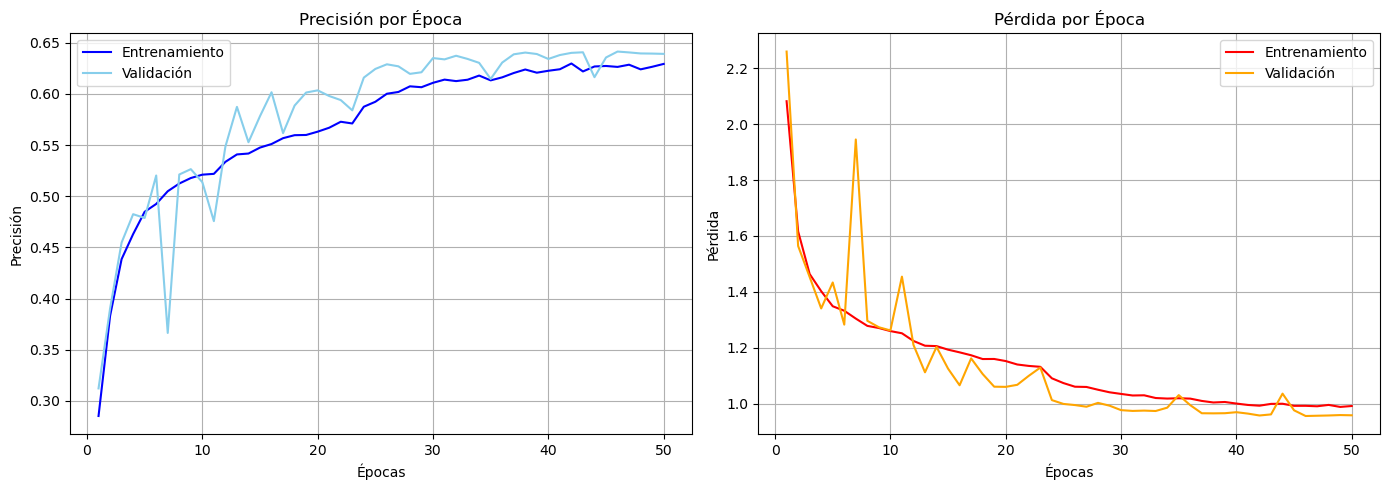

In [8]:
# Extraer métricas
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Crear figura con 2 subplots (1 fila, 2 columnas)
plt.figure(figsize=(14, 5))

# Subplot 1: Precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento', color='blue')
plt.plot(epochs_range, val_acc, label='Validación', color='skyblue')
plt.title('Precisión por Época')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

# Subplot 2: Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento', color='red')
plt.plot(epochs_range, val_loss, label='Validación', color='orange')
plt.title('Pérdida por Época')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
              precision    recall  f1-score   support

       angry       0.44      0.50      0.47         8
     disgust       0.00      0.00      0.00         2
        fear       0.20      0.17      0.18         6
       happy       0.84      0.76      0.80        21
     neutral       0.44      0.64      0.52        11
         sad       0.56      0.45      0.50        11
    surprise       0.67      0.80      0.73         5

    accuracy                           0.58        64
   macro avg       0.45      0.47      0.46        64
weighted avg       0.57      0.58      0.57        64



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


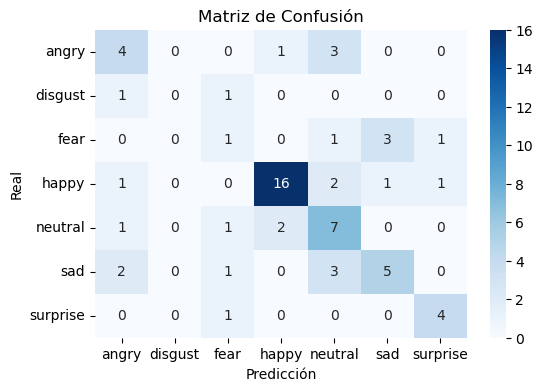

In [10]:
# Obtener el batch
val_images, val_labels = next(validation_generator)

# Hacer predicciones
predictions = model.predict(val_images)

# Convertir a etiquetas
y_true = np.argmax(val_labels, axis=1)
y_pred = np.argmax(predictions, axis=1)

# Encontrar clases presentes en el batch
labels_presentes = np.unique(np.concatenate([y_true, y_pred]))
class_names_filtrados = [class_names[i] for i in labels_presentes]

# Reporte de clasificación
print(classification_report(y_true, y_pred, labels=labels_presentes, target_names=class_names_filtrados))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=labels_presentes)

# Graficar
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_filtrados,
            yticklabels=class_names_filtrados)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

### Verificacion del Codigo

In [11]:
from tensorflow.keras.preprocessing import image

def detect_emotion(image_path):
    # Cargar la imagen en escala de grises y redimensionarla a 48x48 píxeles
    img = image.load_img(image_path, target_size=(48, 48), color_mode='grayscale')
    
    # Convertir la imagen a un arreglo NumPy y normalizar los valores entre 0 y 1
    img_array = image.img_to_array(img) / 255.0
    
    # Expandir las dimensiones para que tenga el formato (1, 48, 48, 1)
    img_array = np.expand_dims(img_array, axis=0)

    # Realizar la predicción usando el modelo
    prediction = model.predict(img_array)
    
    # Obtener el índice de la clase con mayor probabilidad
    predicted_index = np.argmax(prediction)
    
    # Obtener el nombre de la clase correspondiente
    predicted_class = class_names[predicted_index]
    
    # Redondear la confianza al porcentaje con dos decimales
    confidence = round(prediction[0][predicted_index] * 100, 2)  # Confianza en %

    # Mostrar la imagen con la etiqueta y la confianza predicha
    plt.imshow(img, cmap='gray')
    plt.title(f'Emoción Predicha: {predicted_class} ({confidence}%)')
    plt.axis('off')
    plt.show()

    # Retornar la clase predicha y la confianza
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step


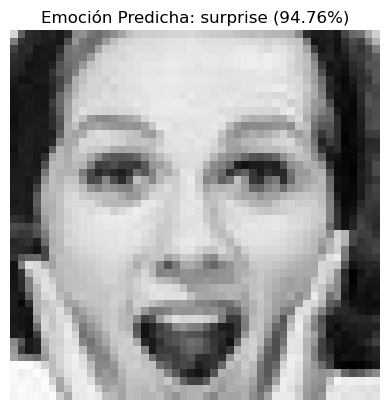

Emoción: surprise, Confianza: 94.76%


In [12]:
# Ejemplo de detección con una imagen local en Windows
predicted_emotion, confidence = detect_emotion(r'E:\Trabajo\emociones\images\train\surprise\10011.jpg')
print(f"Emoción: {predicted_emotion}, Confianza: {confidence}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


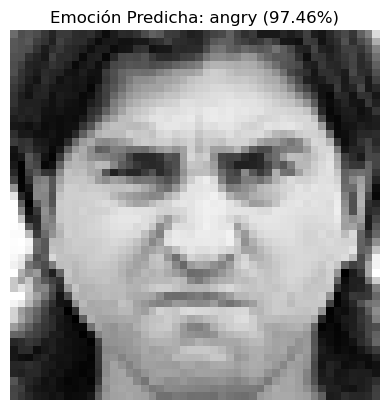

Emoción: angry, Confianza: 97.46%


In [13]:
emotion, confidence = detect_emotion(r'E:\Trabajo\emociones\images\train\angry\10207.jpg')
print(f"Emoción: {emotion}, Confianza: {confidence}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


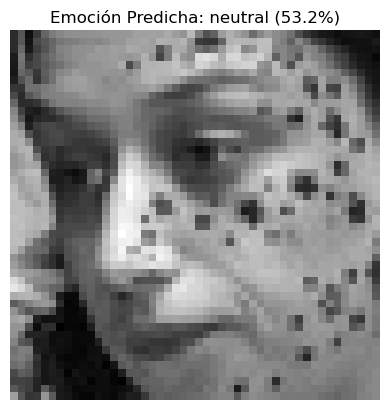

Emoción: neutral, Confianza: 53.2%


In [14]:
# Ejemplo de detección con impresión clara
emoción, confianza = detect_emotion(r'E:\Trabajo\emociones\images\train\sad\10070.jpg')
print(f"Emoción: {emoción}, Confianza: {confianza}%")


#### Guardado de Modelo

In [15]:
model.save('facial_emotion_detection_model.h5')

In [16]:
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']